# GNM-Contact Learner: MSA-Enabled Training

300 protein, ColabFold MSA, full loss (contact + GNM + recon).


## 1. Environment Setup

In [19]:
# ══════════════════════════════════════════════════════════════════
#  CELL 1: Install Dependencies
# ══════════════════════════════════════════════════════════════════
!pip install -q biopython requests wandb

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.10.0+cu128
CUDA: True
GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


In [20]:
# ══════════════════════════════════════════════════════════════════
#  CELL 2: Clone / Update Repository
# ══════════════════════════════════════════════════════════════════
import os
from pathlib import Path

REPO_DIR = Path('/content/ANM-openfold3')

if REPO_DIR.exists():
    !cd {REPO_DIR} && git pull
else:
    !git clone https://github.com/beratkaskaloglu/ANM-openfold3.git {REPO_DIR}

os.chdir(str(REPO_DIR))
print(f"Working dir: {os.getcwd()}")
!git log --oneline -5

Already up to date.
Working dir: /content/ANM-openfold3
36fe337 (HEAD -> main, origin/main, origin/HEAD) fix: normalize reconstruction loss by z std
697bd22 fix: add strict=False to load_state_dict in train notebook
fc8b078 feat: learned inverse MLP for ContactProjectionHead
5489dd7 feat: add manual mode selection strategy
353d929 feat: add z_direction param for +/- delta_z vector application


In [21]:
# ══════════════════════════════════════════════════════════════════
#  CELL 3: Setup OpenFold3 (clone + install)
# ══════════════════════════════════════════════════════════════════
OF3_DIR = Path('/content/ANM-openfold3/openfold3-repo')

if not OF3_DIR.exists():
    !git clone https://github.com/aqlaboratory/openfold-3.git {OF3_DIR}

# Always install — subprocess scripts need it in site-packages
!pip install -e {OF3_DIR} -q

import sys
sys.path.insert(0, str(OF3_DIR))
sys.path.insert(0, str(REPO_DIR))

# Verify
try:
    from openfold3.entry_points.validator import InferenceExperimentConfig
    from openfold3.entry_points.experiment_runner import InferenceExperimentRunner
    print('OpenFold3 OK')
except ImportError as e:
    print(f'FAILED: {e}')

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for openfold3 (pyproject.toml) ... done
OpenFold3 OK


In [22]:
# ══════════════════════════════════════════════════════════════════
#  CELL 3b: Download OpenFold3 Weights
#
#  OF3 model weights interaktif yes/no soruyor.
#  Bu cell onlari onceden indiriyor.
#  Zaten varsa (~/.openfold3/) skip eder.
# ══════════════════════════════════════════════════════════════════
from pathlib import Path

weights_path = Path.home() / ".openfold3" / "of3-p2-155k.pt"

if weights_path.exists():
    print(f"Weights already cached: {weights_path} ({weights_path.stat().st_size / 1e9:.1f} GB)")
else:
    print("Downloading OpenFold3 weights...")
    !echo yes | python -c "import sys; sys.path.insert(0,'/content/ANM-openfold3/openfold3-repo'); from openfold3.entry_points.validator import InferenceExperimentConfig; from openfold3.entry_points.experiment_runner import InferenceExperimentRunner; config = InferenceExperimentConfig(); runner = InferenceExperimentRunner(config, num_diffusion_samples=1, num_model_seeds=1, use_msa_server=False, use_templates=False, output_dir='/tmp/of3_wt_test'); runner.setup(); print('OK')"
    if weights_path.exists():
        print(f"Downloaded: {weights_path} ({weights_path.stat().st_size / 1e9:.1f} GB)")
    else:
        print("WARNING: download may have failed")


Weights already cached: /root/.openfold3/of3-p2-155k.pt (2.3 GB)


## 2. Phase 1 — PDB Curation (2000 proteins)

In [10]:
# ══════════════════════════════════════════════════════════════════
#  CELL 4: Fetch 2000 diverse PDBs from RCSB
#
#  Filters: X-ray, ≤2.5Å, 30-500 aa, ≤30% seq identity
#  Resume-safe: skips if data/pdb_2000.json already exists
# ══════════════════════════════════════════════════════════════════
import json

PDB_LIST = Path('data/pdb_2000.json')

if PDB_LIST.exists():
    proteins = json.loads(PDB_LIST.read_text())
    print(f"PDB list already exists: {len(proteins)} proteins")
else:
    !python scripts/fetch_pdb_list.py --target 2000
    proteins = json.loads(PDB_LIST.read_text())
    print(f"Fetched: {len(proteins)} proteins")

# Stats
lengths = [p['length'] for p in proteins]
print(f"Length: min={min(lengths)}, max={max(lengths)}, "
      f"mean={sum(lengths)/len(lengths):.0f}, "
      f"median={sorted(lengths)[len(lengths)//2]}")

PDB list already exists: 2000 proteins
Length: min=30, max=499, mean=208, median=169


## 3. Phase 2+3 — Chunked Inference + Inline Shard Packing

10 protein / inference chunk, 50 protein / .npz shard.

Her 50 protein'den sonra:
1. .pt → .npz shard'a pakle
2. .pt dosyalarını sil (disk max ~1-2 GB)

**~100s / protein → ~55 saat total.**
Resume-safe: tamamlanan shard'lar skip edilir.

In [23]:
# ══════════════════════════════════════════════════════════════════
#  CELL 5: Google Drive Mount + Directories
#
#  Drive'da sadece checkpoints ve progress tutuluyor (< 10 MB).
#  Shardlar local disk'te — egitildikten sonra silinebilir.
#  Session bitince progress sayesinde kaldigin yerden devam eder.
# ══════════════════════════════════════════════════════════════════
from pathlib import Path

# Google Drive mount
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Drive paths (kalici, < 10 MB)
DRIVE_BASE   = Path('/content/drive/MyDrive/ANM-openfold3')
CKPT_DIR     = DRIVE_BASE / 'checkpoints'
PROGRESS_DIR = DRIVE_BASE / 'progress'

# Local paths (hizli I/O, session sonunda silinir)
SHARD_DIR     = Path('/content/shards')
PAIR_REPR_DIR = Path('/content/pair_reprs')
COORDS_DIR    = Path('/content/coords')
OF3_OUTPUT    = Path('/content/of3_output')
QUERY_DIR     = Path('/content/queries')

for d in [CKPT_DIR, PROGRESS_DIR, SHARD_DIR,
          PAIR_REPR_DIR, COORDS_DIR, OF3_OUTPUT, QUERY_DIR]:
    d.mkdir(parents=True, exist_ok=True)
    print(f"  {d}")

# Resume durumu
n_done = len(list(PROGRESS_DIR.glob('shard_*.ok')))
print(f"\nTamamlanan batch: {n_done} ({n_done * 10} protein)")
if (CKPT_DIR / 'latest.pt').exists():
    print(f"Checkpoint: {CKPT_DIR / 'latest.pt'}")
else:
    print("Checkpoint: yok (ilk calisma)")

Mounted at /content/drive
  /content/drive/MyDrive/ANM-openfold3/checkpoints
  /content/drive/MyDrive/ANM-openfold3/progress
  /content/shards
  /content/pair_reprs
  /content/coords
  /content/of3_output
  /content/queries

Tamamlanan batch: 57 (570 protein)
Checkpoint: /content/drive/MyDrive/ANM-openfold3/checkpoints/latest.pt


In [25]:
# ══════════════════════════════════════════════════════════════════
#  CELL 6: MSA-Enabled Shard Generation + Fresh Training
#
#  Phase 1: OpenFold3 inference WITH MSA → shard .npz (Drive'a kaydeder)
#  Phase 2: Tum shard'lar uzerinde 1000 epoch training (bastan)
#
#  ONEMLI: Eski MSA-siz shard'lar kullanilmaz.
#  Yeni shard'lar shards_msa/ dizinine kaydedilir.
#
#  Resume-safe: mevcut .npz shard'lari skip eder.
# ══════════════════════════════════════════════════════════════════
import os, sys, time, json, importlib
import numpy as np
import torch
import torch.nn.functional as F
from pathlib import Path
from torch.utils.data import DataLoader, Subset

sys.path.insert(0, '/content/ANM-openfold3')

# Force reload to pick up latest code after git pull
import src.kirchhoff, src.losses, src.contact_head, src.data
importlib.reload(src.kirchhoff)
importlib.reload(src.losses)
importlib.reload(src.contact_head)
importlib.reload(src.data)

from src.contact_head import ContactProjectionHead
from src.data import ShardedPairReprDataset
from src.losses import total_loss
from src.kirchhoff import soft_kirchhoff, gnm_decompose

# ╔══════════════════════════════════════════════════════════════╗
# ║  CONFIG                                                      ║
# ╚══════════════════════════════════════════════════════════════╝
TOTAL_PROTEINS    = 300
INFER_BATCH       = 10
C_Z               = 128
BOTTLENECK_DIM    = 64
R_CUT             = 8.0
TAU               = 1.0
DEVICE            = 'cuda' if torch.cuda.is_available() else 'cpu'

# MSA Configuration
USE_MSA_SERVER    = True       # ColabFold MSA — MUST be True for proper training

# Training hyperparameters
FT_EPOCHS         = 1000
FT_LR             = 3e-4       # was 5e-4, tuned down
FT_WEIGHT_DECAY   = 1e-2
FT_PATIENCE       = 80
FT_GRAD_CLIP      = 1.0
FT_GRAD_ACCUM     = 4
FT_LOG_EVERY      = 10
FT_SAVE_EVERY     = 100

# Loss weights — full training (contact + GNM + recon)
ALPHA             = 0.2        # Contact loss (focal)
BETA              = 0.5        # GNM eigenvalue loss
GAMMA             = 2.0       # Reconstruction loss
N_MODES           = 20
SEQ_SEP_MIN       = 6

# Train from scratch — do NOT load old MSA-less checkpoints
TRAIN_FROM_SCRATCH = False

# Shard'lar Drive'a — yeni MSA-li dizin (eski shard'larla karismaz)
SHARD_DIR_DRIVE = Path('/content/drive/MyDrive/ANM-openfold3/shards_msa')
SHARD_DIR_DRIVE.mkdir(parents=True, exist_ok=True)

# Eski shard'lar var mi kontrol et
old_shard_dir = Path('/content/drive/MyDrive/ANM-openfold3/shards')
if old_shard_dir.exists():
    old_count = len(list(old_shard_dir.glob('shard_*.npz')))
    if old_count > 0:
        print(f"!! Eski MSA-siz shard'lar bulundu: {old_shard_dir} ({old_count} shard)")
        print(f"   Bu shard'lar KULLANILMAYACAK. Yeni MSA-li shard'lar: {SHARD_DIR_DRIVE}")

# ╔══════════════════════════════════════════════════════════════╗
# ║  PHASE 1: MSA-Enabled Shard Generation                      ║
# ╚══════════════════════════════════════════════════════════════╝
existing_shards = sorted(SHARD_DIR_DRIVE.glob('shard_*.npz'))
existing_proteins = 0
for sp in existing_shards:
    try:
        with np.load(sp, allow_pickle=True) as data:
            n = 0
            for j in range(len(data['pdb_ids'])):
                if f'pair_repr_{j}' in data:
                    n += 1
                else:
                    break
            existing_proteins += n
    except Exception as e:
        print(f"[Cleanup] Corrupt shard {sp.name}: {e}")
        sp.unlink()

print(f"MSA-li shard'lar: {len(existing_shards)} shard, {existing_proteins} protein")

if existing_proteins >= TOTAL_PROTEINS:
    print(f"Yeterli protein mevcut ({existing_proteins} >= {TOTAL_PROTEINS}), inference skip.")
else:
    needed = TOTAL_PROTEINS - existing_proteins
    start_from = existing_proteins
    print(f"{needed} protein daha lazim (protein {start_from}'dan baslayacak)")
    print(f"MSA Server: {'ENABLED' if USE_MSA_SERVER else 'DISABLED'}")

    n_batches = (needed + INFER_BATCH - 1) // INFER_BATCH
    t0_phase1 = time.time()

    for i in range(n_batches):
        start = start_from + i * INFER_BATCH
        end = min(start + INFER_BATCH, TOTAL_PROTEINS)

        shard_name = f"shard_{start // INFER_BATCH:04d}.npz"
        if (SHARD_DIR_DRIVE / shard_name).exists():
            print(f"  Shard {shard_name} zaten var, skip")
            continue

        print(f"\n  Batch {i+1}/{n_batches}: proteins {start}-{end}")

        local_shard = Path('/content/shards_msa_tmp')
        local_shard.mkdir(exist_ok=True)

        import subprocess
        msa_flag = ['--use-msa-server'] if USE_MSA_SERVER else []
        infer_cmd = [
            'python', 'scripts/extract_pairs.py',
            '--pdb-list', 'data/pdb_2000.json',
            '--shard-size', str(INFER_BATCH),
            '--inference-chunk-size', str(INFER_BATCH),
            '--start', str(start), '--end', str(end),
            '--pair-repr-dir', str(PAIR_REPR_DIR),
            '--coords-dir', str(COORDS_DIR),
            '--output-dir', str(OF3_OUTPUT),
            '--query-dir', str(QUERY_DIR),
            '--shard-dir', str(local_shard),
            '--progress-dir', str(PROGRESS_DIR),
        ] + msa_flag
        result = subprocess.run(
            infer_cmd,
            cwd='/content/ANM-openfold3',
            capture_output=True, text=True,
        )
        if result.returncode != 0:
            print(f"  STDERR: {result.stderr[-2000:]}")
        print(f"  Inference exit={result.returncode}")

        import shutil
        for f in sorted(local_shard.glob('shard_*.npz')):
            dst = SHARD_DIR_DRIVE / f.name
            if not dst.exists():
                shutil.copy2(f, dst)
                print(f"  -> Drive'a kopyalandi: {f.name}")

        torch.cuda.empty_cache()

    t_phase1 = time.time() - t0_phase1
    print(f"\n[Phase 1] Tamamlandi: {t_phase1/60:.1f} dk")

# ╔══════════════════════════════════════════════════════════════╗
# ║  PHASE 2: Fresh Training (1000 epochs)                       ║
# ╚══════════════════════════════════════════════════════════════╝
shard_paths = sorted(SHARD_DIR_DRIVE.glob('shard_*.npz'))
print(f"\nShards: {len(shard_paths)}")

valid_shards = []
for sp in shard_paths:
    try:
        with np.load(sp, allow_pickle=True) as data:
            if len(data['pdb_ids']) > 0 and 'pair_repr_0' in data:
                valid_shards.append(sp)
    except Exception:
        print(f"[Skip] Corrupt: {sp.name}")
shard_paths = valid_shards

dataset = ShardedPairReprDataset(shard_paths, r_cut=R_CUT, tau=TAU)
n_total = len(dataset)
print(f"Total proteins: {n_total}")

if n_total < 3:
    raise RuntimeError(f"Yetersiz protein: {n_total}. Inference gerekli.")

indices = list(range(n_total))
rng = np.random.RandomState(42)
rng.shuffle(indices)
n_test = max(1, int(n_total * 0.1))
n_val = max(1, int(n_total * 0.1))
n_train = n_total - n_val - n_test

train_ds = Subset(dataset, indices[:n_train])
val_ds = Subset(dataset, indices[n_train:n_train+n_val])
test_ds = Subset(dataset, indices[n_train+n_val:])
print(f"Split: train={n_train}, val={n_val}, test={n_test}")

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

# Model — fresh initialization
head = ContactProjectionHead(c_z=C_Z, bottleneck_dim=BOTTLENECK_DIM).to(DEVICE)

# Checkpoint directory — MSA-specific
ft_ckpt_dir = Path('/content/drive/MyDrive/ANM-openfold3/checkpoints/finetune_msa')
ft_ckpt_dir.mkdir(parents=True, exist_ok=True)

if TRAIN_FROM_SCRATCH:
    print("Training from scratch (MSA-enabled, no old checkpoint)")
else:
    # Only resume from MSA-specific checkpoints
    ckpt_path = None
    for candidate in [
        ft_ckpt_dir / 'best_model.pt',
        ft_ckpt_dir / 'latest.pt',
    ]:
        if candidate.exists():
            ckpt_path = candidate
            break

    if ckpt_path is not None:
        ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        if ckpt.get('bottleneck_dim', 64) == BOTTLENECK_DIM:
            head.load_state_dict(ckpt['model_state_dict'], strict=False)
            print(f"Resumed from {ckpt_path} (val_loss={ckpt.get('val_loss', '?')})")
        else:
            print(f"Checkpoint bottleneck_dim mismatch, training from scratch")
    else:
        print("No MSA checkpoint found, training from scratch")

n_params = sum(p.numel() for p in head.parameters())
print(f"Parameters: {n_params:,}")

optimizer = torch.optim.AdamW(head.parameters(), lr=FT_LR, weight_decay=FT_WEIGHT_DECAY)
total_steps = FT_EPOCHS * len(train_loader)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=FT_LR, total_steps=total_steps,
    pct_start=0.05, anneal_strategy='cos',
    div_factor=1.0, final_div_factor=100.0,
)

def pearson_corr(x, y):
    xc, yc = x - x.mean(), y - y.mean()
    return ((xc * yc).sum() / (xc.norm() * yc.norm()).clamp(min=1e-8)).item()

def adj_accuracy(c_pred, c_gt, thr=0.5):
    return ((c_pred > thr).float() == (c_gt > thr).float()).float().mean().item()

history = []
best_val_loss = float('inf')
epochs_no_improve = 0

print(f"\n{'='*60}")
print(f"  TRAINING: {FT_EPOCHS} epochs, lr={FT_LR}, {n_train} proteins")
print(f"  MSA={USE_MSA_SERVER}, ALPHA={ALPHA}, BETA={BETA}, GAMMA={GAMMA}")
print(f"  grad_accum={FT_GRAD_ACCUM}, patience={FT_PATIENCE}")
print(f"  Checkpoints: {ft_ckpt_dir}")
print(f"{'='*60}\n")

t0_all = time.time()

for epoch in range(FT_EPOCHS):
    # ── Train ──
    head.train()
    train_loss_sum, train_n = 0.0, 0
    optimizer.zero_grad()

    for step, batch in enumerate(train_loader):
        try:
            z = batch['pair_repr'].to(DEVICE)
            c_gt = batch['c_gt'].to(DEVICE)
            if z.dim() == 5: z = z.squeeze(0)
            if c_gt.dim() == 3: c_gt = c_gt.squeeze(0)

            c_pred = head(z).squeeze(0)

            z_sym = 0.5 * (z + z.transpose(1, 2)).squeeze(0)
            z_recon = head.inverse(c_pred)

            loss, details = total_loss(
                c_pred, c_gt,
                z_original=z_sym, z_reconstructed=z_recon,
                alpha=ALPHA, beta=BETA, gamma=GAMMA, n_modes=N_MODES,
                use_focal=True, focal_gamma=2.0, focal_alpha=0.75,
                seq_sep_min=SEQ_SEP_MIN,
            )

            if torch.isnan(loss) or torch.isinf(loss):
                optimizer.zero_grad()
                continue

            (loss / FT_GRAD_ACCUM).backward()

            if (step + 1) % FT_GRAD_ACCUM == 0 or (step + 1) == len(train_loader):
                torch.nn.utils.clip_grad_norm_(head.parameters(), FT_GRAD_CLIP)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()

            train_loss_sum += loss.item()
            train_n += 1
        except RuntimeError as e:
            print(f"    [SKIP] Train step {step}: {e}")
            optimizer.zero_grad()
            torch.cuda.empty_cache()
            continue

    avg_train = train_loss_sum / max(train_n, 1)

    # ── Validate ──
    head.eval()
    val_loss_sum, val_acc_sum, val_bf_sum, val_n = 0.0, 0.0, 0.0, 0

    with torch.no_grad():
        for batch in val_loader:
            try:
                z = batch['pair_repr'].to(DEVICE)
                c_gt = batch['c_gt'].to(DEVICE)
                if z.dim() == 5: z = z.squeeze(0)
                if c_gt.dim() == 3: c_gt = c_gt.squeeze(0)

                c_pred = head(z).squeeze(0)

                z_sym = 0.5 * (z + z.transpose(1, 2)).squeeze(0)
                z_recon = head.inverse(c_pred)

                loss, _ = total_loss(
                    c_pred, c_gt,
                    z_original=z_sym, z_reconstructed=z_recon,
                    alpha=ALPHA, beta=BETA, gamma=GAMMA,
                    n_modes=N_MODES, use_focal=True,
                    seq_sep_min=SEQ_SEP_MIN,
                )

                acc = adj_accuracy(c_pred, c_gt)
                gamma_p = soft_kirchhoff(c_pred)
                gamma_g = soft_kirchhoff(c_gt)
                _, _, bf_p = gnm_decompose(gamma_p, N_MODES)
                _, _, bf_g = gnm_decompose(gamma_g, N_MODES)
                bf_r = pearson_corr(bf_p, bf_g)

                val_loss_sum += loss.item()
                val_acc_sum += acc
                val_bf_sum += bf_r
                val_n += 1
            except RuntimeError as e:
                print(f"    [SKIP] Val: {e}")
                torch.cuda.empty_cache()
                continue

    avg_val = val_loss_sum / max(val_n, 1)
    avg_acc = val_acc_sum / max(val_n, 1)
    avg_bf = val_bf_sum / max(val_n, 1)
    lr_now = optimizer.param_groups[0]['lr']

    record = {
        'epoch': epoch + 1,
        'train_loss': avg_train,
        'val_loss': avg_val,
        'val_adj_acc': avg_acc,
        'val_bf_pearson': avg_bf,
        'lr': lr_now,
    }
    history.append(record)

    if (epoch + 1) % FT_LOG_EVERY == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:4d}/{FT_EPOCHS}  "
              f"train={avg_train:.4f}  val={avg_val:.4f}  "
              f"acc={avg_acc:.3f}  bf_r={avg_bf:.3f}  lr={lr_now:.1e}")

    if avg_val < best_val_loss - 1e-5:
        best_val_loss = avg_val
        epochs_no_improve = 0
        torch.save({
            'model_state_dict': head.state_dict(),
            'epoch': epoch,
            'val_loss': best_val_loss,
            'val_adj_acc': avg_acc,
            'val_bf_pearson': avg_bf,
            'c_z': C_Z,
            'bottleneck_dim': BOTTLENECK_DIM,
            'msa_enabled': True,
            'alpha': ALPHA, 'beta': BETA, 'gamma': GAMMA,
        }, ft_ckpt_dir / 'best_model.pt')
    else:
        epochs_no_improve += 1

    if (epoch + 1) % FT_SAVE_EVERY == 0:
        torch.save({
            'model_state_dict': head.state_dict(),
            'epoch': epoch, 'val_loss': avg_val,
            'c_z': C_Z, 'bottleneck_dim': BOTTLENECK_DIM,
            'msa_enabled': True,
        }, ft_ckpt_dir / f'epoch_{epoch+1:04d}.pt')

    torch.save({
        'model_state_dict': head.state_dict(),
        'epoch': epoch, 'val_loss': avg_val,
        'c_z': C_Z, 'bottleneck_dim': BOTTLENECK_DIM,
        'msa_enabled': True,
    }, ft_ckpt_dir / 'latest.pt')

    if epochs_no_improve >= FT_PATIENCE:
        print(f"\n  Early stopping at epoch {epoch+1} (no improve for {FT_PATIENCE} epochs)")
        break

(ft_ckpt_dir / 'history.json').write_text(json.dumps(history, indent=2))
total_time = time.time() - t0_all

# ╔══════════════════════════════════════════════════════════════╗
# ║  TEST EVALUATION                                             ║
# ╚══════════════════════════════════════════════════════════════╝
print(f"\n{'='*60}")
print(f"  TRAINING COMPLETE")
print(f"  Total time: {total_time/60:.1f} min")
print(f"  Best val loss: {best_val_loss:.4f}")
print(f"{'='*60}")

best_ckpt = torch.load(ft_ckpt_dir / 'best_model.pt', map_location=DEVICE, weights_only=False)
head.load_state_dict(best_ckpt['model_state_dict'], strict=False)
head.eval()

test_loss_sum, test_acc_sum, test_bf_sum, test_n = 0.0, 0.0, 0.0, 0
with torch.no_grad():
    for batch in test_loader:
        z = batch['pair_repr'].to(DEVICE)
        c_gt = batch['c_gt'].to(DEVICE)
        if z.dim() == 5: z = z.squeeze(0)
        if c_gt.dim() == 3: c_gt = c_gt.squeeze(0)

        c_pred = head(z).squeeze(0)
        z_sym = 0.5 * (z + z.transpose(1, 2)).squeeze(0)
        z_recon = head.inverse(c_pred)

        loss, _ = total_loss(
            c_pred, c_gt,
            z_original=z_sym, z_reconstructed=z_recon,
            alpha=ALPHA, beta=BETA, gamma=GAMMA,
            n_modes=N_MODES, use_focal=True, seq_sep_min=SEQ_SEP_MIN,
        )
        acc = adj_accuracy(c_pred, c_gt)
        gamma_p = soft_kirchhoff(c_pred)
        gamma_g = soft_kirchhoff(c_gt)
        _, _, bf_p = gnm_decompose(gamma_p, N_MODES)
        _, _, bf_g = gnm_decompose(gamma_g, N_MODES)
        bf_r = pearson_corr(bf_p, bf_g)

        test_loss_sum += loss.item()
        test_acc_sum += acc
        test_bf_sum += bf_r
        test_n += 1

test_metrics = {
    'loss': test_loss_sum / max(test_n, 1),
    'adj_acc': test_acc_sum / max(test_n, 1),
    'bf_pearson': test_bf_sum / max(test_n, 1),
}

print(f"\n  TEST RESULTS:")
print(f"    Loss:          {test_metrics['loss']:.4f}")
print(f"    Adj accuracy:  {test_metrics['adj_acc']:.4f}")
print(f"    B-factor r:    {test_metrics['bf_pearson']:.4f}")

targets = {'adj_acc': 0.85, 'bf_pearson': 0.80}
for k, v in targets.items():
    status = 'PASS' if test_metrics[k] >= v else 'FAIL'
    print(f"    {k}: {test_metrics[k]:.4f} vs target {v:.2f} -> {status}")

test_results = {
    'test_metrics': test_metrics,
    'best_epoch': best_ckpt['epoch'] + 1,
    'best_val_loss': float(best_ckpt['val_loss']),
    'total_epochs': epoch + 1,
    'total_time_min': total_time / 60,
    'n_train': n_train, 'n_val': n_val, 'n_test': n_test,
    'msa_enabled': True,
    'loss_weights': {'alpha': ALPHA, 'beta': BETA, 'gamma': GAMMA},
}
(ft_ckpt_dir / 'test_results.json').write_text(json.dumps(test_results, indent=2))

MSA-li shard'lar: 30 shard, 293 protein
7 protein daha lazim (protein 293'dan baslayacak)
MSA Server: ENABLED
  Shard shard_0029.npz zaten var, skip

[Phase 1] Tamamlandi: 0.0 dk

Shards: 30
Total proteins: 293
Split: train=235, val=29, test=29
Resumed from /content/drive/MyDrive/ANM-openfold3/checkpoints/finetune_msa/best_model.pt (val_loss=1.902463152490813)
Parameters: 24,896

  TRAINING: 1000 epochs, lr=0.0003, 235 proteins
  MSA=True, ALPHA=0.2, BETA=0.5, GAMMA=2.0
  grad_accum=4, patience=80
  Checkpoints: /content/drive/MyDrive/ANM-openfold3/checkpoints/finetune_msa

  Epoch    1/1000  train=1.8084  val=1.9150  acc=0.981  bf_r=0.809  lr=3.0e-04
  Epoch   10/1000  train=1.8073  val=1.9203  acc=0.978  bf_r=0.796  lr=3.0e-04
  Epoch   20/1000  train=1.8087  val=1.9170  acc=0.981  bf_r=0.812  lr=3.0e-04
  Epoch   30/1000  train=1.8080  val=1.9163  acc=0.980  bf_r=0.806  lr=3.0e-04
  Epoch   40/1000  train=1.8077  val=1.9141  acc=0.980  bf_r=0.807  lr=3.0e-04
  Epoch   50/1000  train

399

## 4. Results & Visualization


/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )("sym").leaveWhitespace()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1984: PyparsingDeprecationWarning: 'setName' deprecated - use 'set_name'
  val.setName(key)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1987: PyparsingDeprecationWarning: 'setParseA

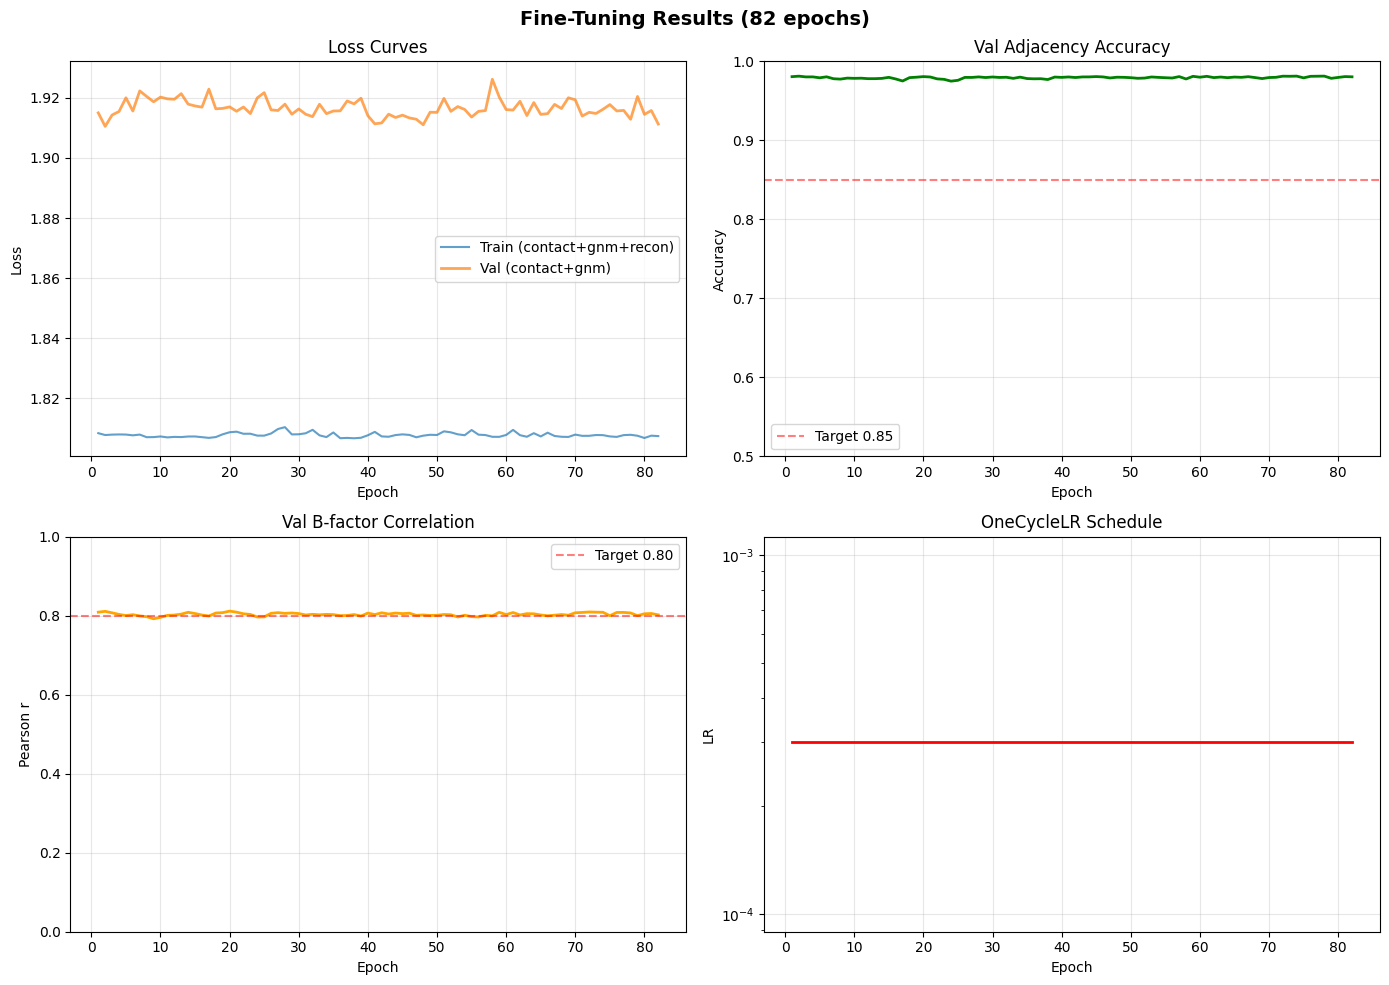

Best epoch: 2
  val_loss:    1.9105
  adj_acc:     0.981
  bf_pearson:  0.811


In [26]:
# ══════════════════════════════════════════════════════════════════
#  CELL 11: Fine-Tuning Training Curves
# ══════════════════════════════════════════════════════════════════
import json
from pathlib import Path
import matplotlib.pyplot as plt

ft_ckpt_dir = Path('/content/drive/MyDrive/ANM-openfold3/checkpoints/finetune_msa')
history = json.loads((ft_ckpt_dir / 'history.json').read_text())

epochs = [h['epoch'] for h in history]
train_loss = [h['train_loss'] for h in history]
val_loss = [h['val_loss'] for h in history]
val_acc = [h['val_adj_acc'] for h in history]
val_bf = [h['val_bf_pearson'] for h in history]
lrs = [h['lr'] for h in history]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Fine-Tuning Results ({len(history)} epochs)', fontsize=14, fontweight='bold')

# Loss
axes[0,0].plot(epochs, train_loss, label='Train (contact+gnm+recon)', alpha=0.7)
axes[0,0].plot(epochs, val_loss, label='Val (contact+gnm)', alpha=0.7, linewidth=2)
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].set_title('Loss Curves')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Adjacency Accuracy
axes[0,1].plot(epochs, val_acc, color='green', linewidth=2)
axes[0,1].axhline(y=0.85, color='red', linestyle='--', alpha=0.5, label='Target 0.85')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Accuracy')
axes[0,1].set_title('Val Adjacency Accuracy')
axes[0,1].set_ylim(0.5, 1.0)
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# B-factor correlation
axes[1,0].plot(epochs, val_bf, color='orange', linewidth=2)
axes[1,0].axhline(y=0.80, color='red', linestyle='--', alpha=0.5, label='Target 0.80')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Pearson r')
axes[1,0].set_title('Val B-factor Correlation')
axes[1,0].set_ylim(0.0, 1.0)
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Learning rate
axes[1,1].plot(epochs, lrs, color='red', linewidth=2)
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('LR')
axes[1,1].set_title('OneCycleLR Schedule')
axes[1,1].set_yscale('log')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(ft_ckpt_dir / 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print summary
best_epoch = min(history, key=lambda h: h['val_loss'])
print(f"Best epoch: {best_epoch['epoch']}")
print(f"  val_loss:    {best_epoch['val_loss']:.4f}")
print(f"  adj_acc:     {best_epoch['val_adj_acc']:.3f}")
print(f"  bf_pearson:  {best_epoch['val_bf_pearson']:.3f}")

In [ ]:
from pathlib import Path
# ══════════════════════════════════════════════════════════════════
#  CELL 12: Test Set Results
# ══════════════════════════════════════════════════════════════════
import json

ft_ckpt_dir = Path('/content/drive/MyDrive/ANM-openfold3/checkpoints/finetune_msa')
test_results = json.loads((ft_ckpt_dir / 'test_results.json').read_text())

print("=" * 50)
print("  FINE-TUNING TEST SET RESULTS")
print("=" * 50)
print(f"  Best epoch:      {test_results['best_epoch']}")
print(f"  Best val loss:   {test_results['best_val_loss']:.4f}")
print(f"  Total epochs:    {test_results['total_epochs']}")
print(f"  Training time:   {test_results['total_time_min']:.1f} min")
print(f"  Data split:      {test_results['n_train']}/"
      f"{test_results['n_val']}/{test_results['n_test']}")
print()
m = test_results['test_metrics']
print(f"  Test loss:       {m['loss']:.4f}")
print(f"  Adj accuracy:    {m['adj_acc']:.4f}")
print(f"  B-factor r:      {m['bf_pearson']:.4f}")
print("=" * 50)

# Target check
targets = {'adj_acc': 0.85, 'bf_pearson': 0.80}
for k, target in targets.items():
    val = m[k]
    status = 'PASS' if val >= target else 'MISS'
    print(f"  [{status}] {k}: {val:.4f} (target >= {target})")

Loaded best model (epoch 330, val_loss=2.5464)


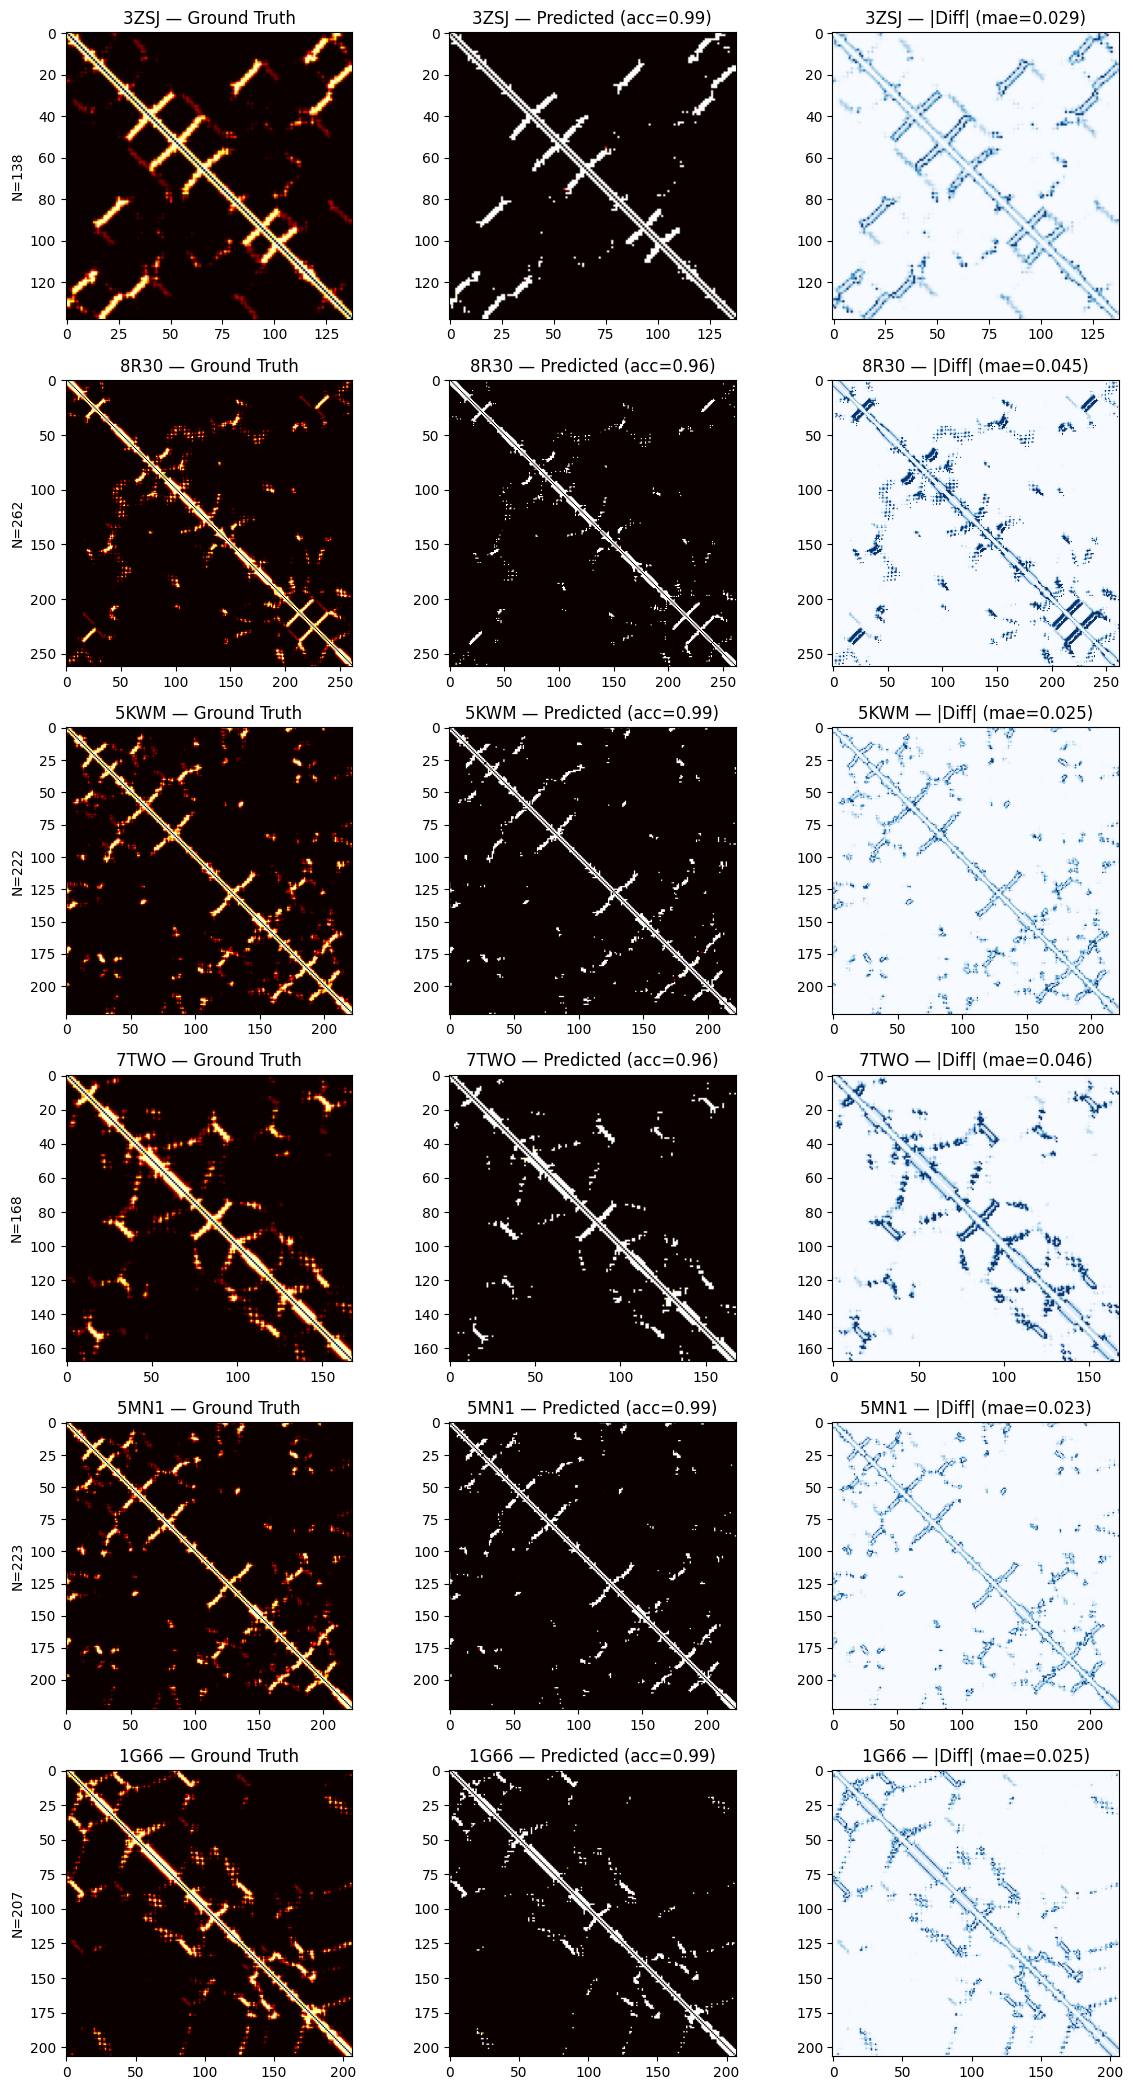

In [25]:
# ══════════════════════════════════════════════════════════════════
#  CELL 13: Contact Map Visualization
# ══════════════════════════════════════════════════════════════════
import sys, numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
sys.path.insert(0, '/content/ANM-openfold3')

from src.contact_head import ContactProjectionHead
from src.data import ShardedPairReprDataset
from src.kirchhoff import soft_kirchhoff, gnm_decompose

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
ft_ckpt_dir = Path('/content/drive/MyDrive/ANM-openfold3/checkpoints/finetune_msa')

# Load best model
ckpt = torch.load(ft_ckpt_dir / 'best_model.pt', map_location=DEVICE, weights_only=False)
head = ContactProjectionHead(c_z=ckpt['c_z'], bottleneck_dim=ckpt['bottleneck_dim']).to(DEVICE)
head.load_state_dict(ckpt['model_state_dict'])
head.eval()
print(f"Loaded best model (epoch {ckpt['epoch']+1}, val_loss={ckpt['val_loss']:.4f})")

# Load dataset
shard_paths = sorted(Path('/content/drive/MyDrive/ANM-openfold3/shards_msa').glob('shard_*.npz'))
dataset = ShardedPairReprDataset(shard_paths, r_cut=8.0, tau=1.0)

# Show 6 random samples
n_show = min(6, len(dataset))
rng = np.random.RandomState(123)
show_idx = rng.choice(len(dataset), n_show, replace=False)

fig, axes = plt.subplots(n_show, 3, figsize=(12, 3.5 * n_show))
if n_show == 1:
    axes = axes[None, :]

with torch.no_grad():
    for row, idx in enumerate(show_idx):
        sample = dataset[idx]
        z = sample['pair_repr'].unsqueeze(0).to(DEVICE)
        c_gt = sample['c_gt'].squeeze().cpu().numpy()
        c_pred = head(z).squeeze().cpu().numpy()
        pdb_id = sample.get('pdb_id', f'protein_{idx}')

        acc = ((c_pred > 0.5) == (c_gt > 0.5)).mean()

        axes[row, 0].imshow(c_gt, cmap='hot', vmin=0, vmax=1)
        axes[row, 0].set_title(f'{pdb_id} — Ground Truth')
        axes[row, 0].set_ylabel(f'N={c_gt.shape[0]}')

        axes[row, 1].imshow(c_pred, cmap='hot', vmin=0, vmax=1)
        axes[row, 1].set_title(f'{pdb_id} — Predicted (acc={acc:.2f})')

        diff = np.abs(c_pred - c_gt)
        axes[row, 2].imshow(diff, cmap='Blues', vmin=0, vmax=0.5)
        axes[row, 2].set_title(f'{pdb_id} — |Diff| (mae={diff.mean():.3f})')

plt.tight_layout()
plt.savefig(str(ft_ckpt_dir / 'contact_maps.png'), dpi=150, bbox_inches='tight')
plt.show()

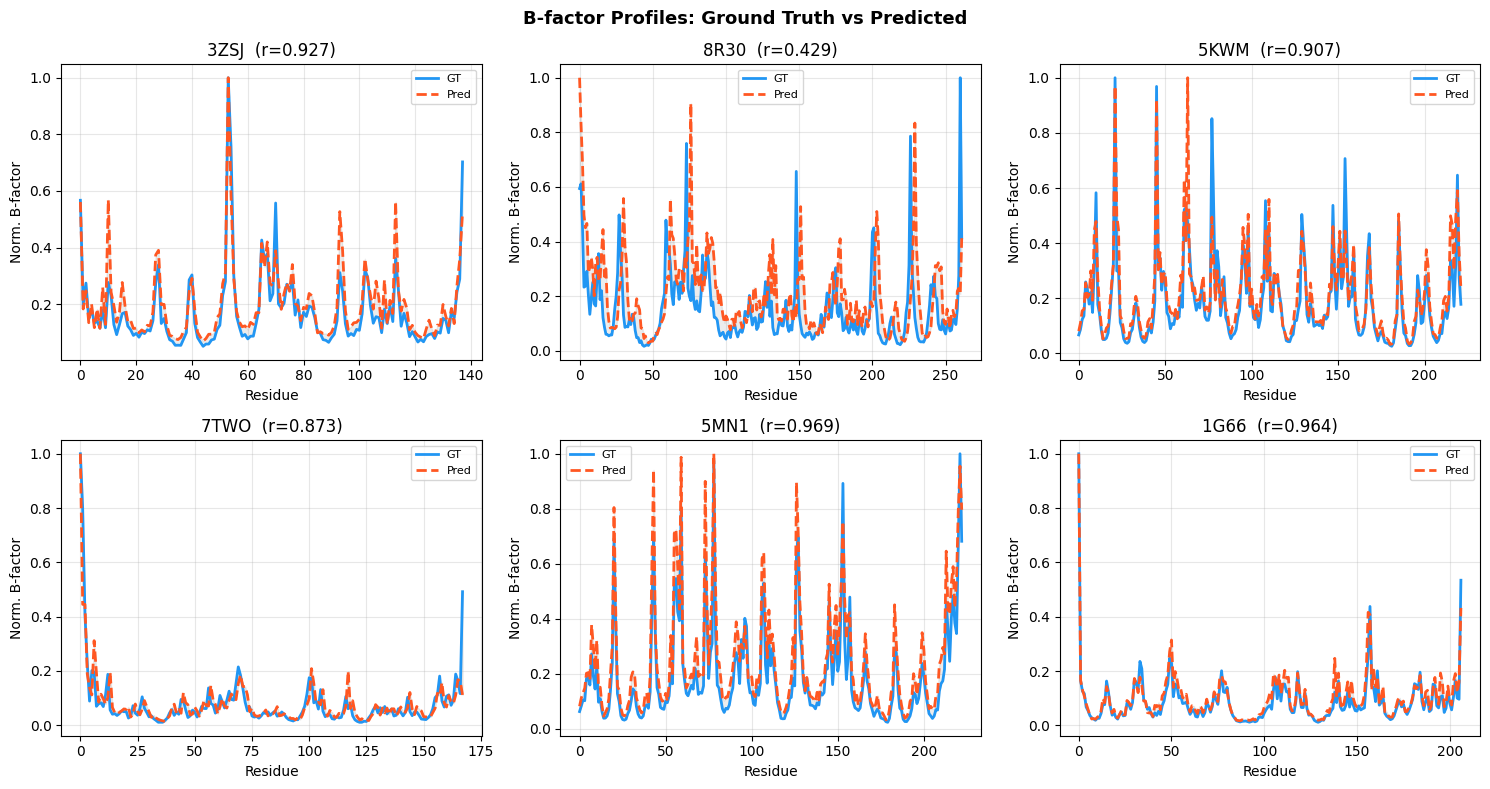

In [27]:
# ══════════════════════════════════════════════════════════════════
#  CELL 14: B-factor Profile Comparison
# ══════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
N_MODES = 20

def pearson_corr(x, y):
    xc, yc = x - x.mean(), y - y.mean()
    return ((xc * yc).sum() / (xc.norm() * yc.norm()).clamp(min=1e-8)).item()

n_show = min(6, len(dataset))
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

with torch.no_grad():
    for i, idx in enumerate(show_idx[:n_show]):
        sample = dataset[idx]
        z = sample['pair_repr'].unsqueeze(0).to(DEVICE)
        c_gt = sample['c_gt'].squeeze().to(DEVICE)
        c_pred = head(z).squeeze()
        pdb_id = sample.get('pdb_id', f'protein_{idx}')

        _, _, bf_gt = gnm_decompose(soft_kirchhoff(c_gt), N_MODES)
        _, _, bf_pred = gnm_decompose(soft_kirchhoff(c_pred), N_MODES)

        bf_gt_n = (bf_gt / bf_gt.max()).cpu().numpy()
        bf_pred_n = (bf_pred / bf_pred.max()).cpu().numpy()
        r = pearson_corr(bf_pred.cpu(), bf_gt.cpu())

        axes[i].plot(bf_gt_n, label='GT', linewidth=2, color='#2196F3')
        axes[i].plot(bf_pred_n, label='Pred', linewidth=2, linestyle='--', color='#FF5722')
        axes[i].fill_between(range(len(bf_gt_n)), bf_gt_n, bf_pred_n, alpha=0.15, color='gray')
        axes[i].set_title(f'{pdb_id}  (r={r:.3f})')
        axes[i].set_xlabel('Residue')
        axes[i].set_ylabel('Norm. B-factor')
        axes[i].legend(fontsize=8)
        axes[i].grid(True, alpha=0.3)

# Hide unused axes
for j in range(n_show, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('B-factor Profiles: Ground Truth vs Predicted', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(ft_ckpt_dir / 'bfactor_profiles.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Adenylate Kinase Test (1AKE open / 4AKE closed)

Klasik ANM benchmark: acik (1AKE) ve kapali (4AKE) konformasyonlari arasinda B-factor, contact map ve GNM analizi.

Model loaded (epoch 2, val_loss=1.9105)
Structure exists: '/tmp/pdb_ake/pdb1ake.ent' 
1AKE: 214 residues, chain A
  adj_acc=0.9999  bf_r=0.9305  contact_mae=0.0179  eig_r=0.9954
Structure exists: '/tmp/pdb_ake/pdb4ake.ent' 
4AKE: 214 residues, chain A
  adj_acc=1.0000  bf_r=0.9689  contact_mae=0.0165  eig_r=0.9925


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


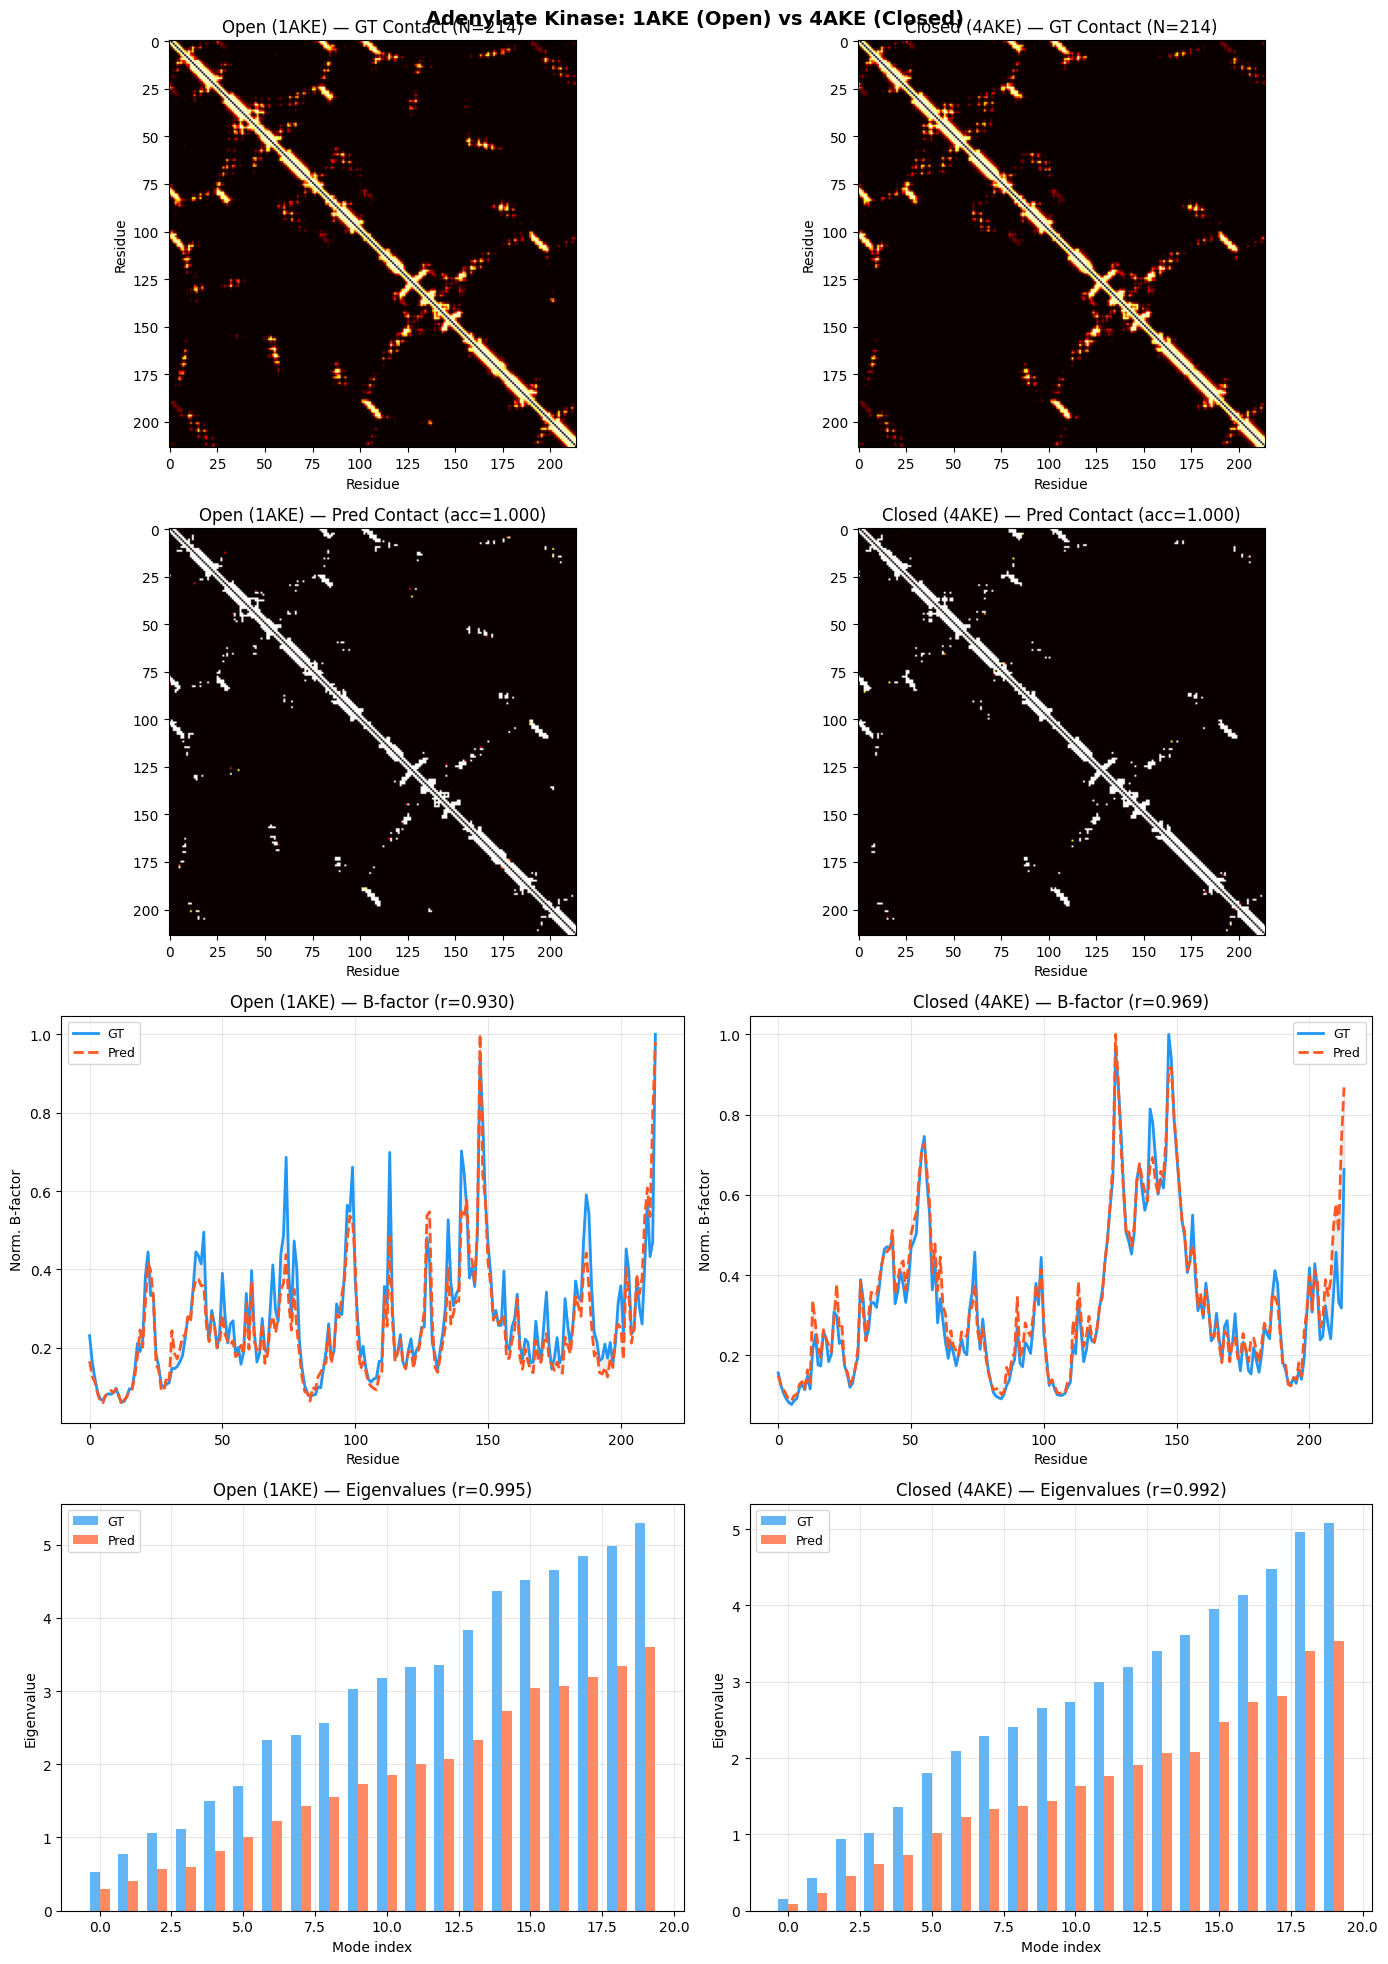


  CROSS-CONFORMATION COMPARISON
  1AKE vs 4AKE GT B-factor r:   0.6459
  1AKE vs 4AKE Pred B-factor r: 0.7142

  Open (1AKE):
    adj_acc=0.9999  bf_r=0.9305  mae=0.0179  eig_r=0.9954
  Closed (4AKE):
    adj_acc=1.0000  bf_r=0.9689  mae=0.0165  eig_r=0.9925


In [27]:
# ══════════════════════════════════════════════════════════════════
#  CELL 16: Adenylate Kinase Test — 1AKE (open) vs 4AKE (closed)
#
#  1. PDB indir → CA coords
#  2. GT contact map → GNM B-factors
#  3. Inverse path → pseudo z_ij → forward head → predicted contact
#  4. Predicted contact → GNM B-factors
#  5. Karsilastirma: GT vs Pred, 1AKE vs 4AKE
# ══════════════════════════════════════════════════════════════════
import sys, torch, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, '/content/ANM-openfold3')

from src.contact_head import ContactProjectionHead
from src.ground_truth import compute_gt_probability_matrix
from src.kirchhoff import soft_kirchhoff, gnm_decompose
from src.data import extract_ca_coords

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
N_MODES = 20
R_CUT = 8.0
TAU = 1.0

# ── Load trained model ───────────────────────────────────────────
ft_ckpt_dir = Path('/content/drive/MyDrive/ANM-openfold3/checkpoints/finetune_msa')
ckpt = torch.load(ft_ckpt_dir / 'best_model.pt', map_location=DEVICE, weights_only=False)
head = ContactProjectionHead(c_z=ckpt['c_z'], bottleneck_dim=ckpt['bottleneck_dim']).to(DEVICE)
head.load_state_dict(ckpt['model_state_dict'])
head.eval()
print(f"Model loaded (epoch {ckpt['epoch']+1}, val_loss={ckpt['val_loss']:.4f})")

# ── Download PDBs ────────────────────────────────────────────────
import Bio.PDB as bpdb

pdb_ids = ['1AKE', '4AKE']
pdb_labels = {'1AKE': 'Open (1AKE)', '4AKE': 'Closed (4AKE)'}
pdb_cache = Path('/tmp/pdb_ake')
pdb_cache.mkdir(exist_ok=True)

pdbl = bpdb.PDBList()
parser = bpdb.PDBParser(QUIET=True)

def pearson(x, y):
    xc, yc = x - x.mean(), y - y.mean()
    return ((xc * yc).sum() / (xc.norm() * yc.norm()).clamp(min=1e-8)).item()

results = {}

for pdb_id in pdb_ids:
    # Download
    pdb_file = pdbl.retrieve_pdb_file(pdb_id, pdir=str(pdb_cache), file_format='pdb')
    structure = parser.get_structure(pdb_id, pdb_file)

    # Extract CA from chain A only
    chain_a = list(structure[0].get_chains())[0]
    ca_coords = []
    for res in chain_a:
        if res.get_id()[0] == ' ' and 'CA' in res:
            ca_coords.append(res['CA'].get_vector().get_array())

    coords = torch.tensor(np.array(ca_coords), dtype=torch.float32)
    print(f"{pdb_id}: {coords.shape[0]} residues, chain {chain_a.id}")

    # ── Ground truth contact & GNM ────────────────────────────
    c_gt = compute_gt_probability_matrix(coords, r_cut=R_CUT, tau=TAU)
    gamma_gt = soft_kirchhoff(c_gt)
    vals_gt, vecs_gt, bf_gt = gnm_decompose(gamma_gt, N_MODES)

    # ── Inverse path: coords → contact → z_pseudo → head → c_pred
    with torch.no_grad():
        c_gt_dev = c_gt.to(DEVICE)
        z_pseudo = head.inverse(c_gt_dev)  # [N, N, c_z]
        c_pred = head(z_pseudo.unsqueeze(0)).squeeze(0)  # [N, N]

    # ── Predicted GNM ─────────────────────────────────────────
    gamma_pred = soft_kirchhoff(c_pred.cpu())
    vals_pred, vecs_pred, bf_pred = gnm_decompose(gamma_pred, N_MODES)

    # ── Metrics ───────────────────────────────────────────────
    bf_r = pearson(bf_pred, bf_gt)
    c_pred_cpu = c_pred.cpu()
    adj_acc = ((c_pred_cpu > 0.5).float() == (c_gt > 0.5).float()).float().mean().item()
    contact_mae = (c_pred_cpu - c_gt).abs().mean().item()
    eig_r = pearson(vals_pred, vals_gt)

    results[pdb_id] = {
        'coords': coords,
        'c_gt': c_gt,
        'c_pred': c_pred_cpu,
        'bf_gt': bf_gt,
        'bf_pred': bf_pred,
        'vals_gt': vals_gt,
        'vals_pred': vals_pred,
        'bf_r': bf_r,
        'adj_acc': adj_acc,
        'contact_mae': contact_mae,
        'eig_r': eig_r,
    }

    print(f"  adj_acc={adj_acc:.4f}  bf_r={bf_r:.4f}  "
          f"contact_mae={contact_mae:.4f}  eig_r={eig_r:.4f}")

# ╔══════════════════════════════════════════════════════════════╗
# ║  VISUALIZATION                                               ║
# ╚══════════════════════════════════════════════════════════════╝

fig, axes = plt.subplots(4, 2, figsize=(14, 20))

for col, pdb_id in enumerate(pdb_ids):
    r = results[pdb_id]
    label = pdb_labels[pdb_id]
    N = r['coords'].shape[0]

    # Row 0: GT Contact map
    axes[0, col].imshow(r['c_gt'].numpy(), cmap='hot', vmin=0, vmax=1, aspect='equal')
    axes[0, col].set_title(f'{label} — GT Contact (N={N})')
    axes[0, col].set_xlabel('Residue')
    axes[0, col].set_ylabel('Residue')

    # Row 1: Predicted contact map
    axes[1, col].imshow(r['c_pred'].numpy(), cmap='hot', vmin=0, vmax=1, aspect='equal')
    axes[1, col].set_title(f'{label} — Pred Contact (acc={r["adj_acc"]:.3f})')
    axes[1, col].set_xlabel('Residue')

    # Row 2: B-factor profiles
    bf_gt_n = (r['bf_gt'] / r['bf_gt'].max()).numpy()
    bf_pred_n = (r['bf_pred'] / r['bf_pred'].max()).numpy()
    axes[2, col].plot(bf_gt_n, label='GT', linewidth=2, color='#2196F3')
    axes[2, col].plot(bf_pred_n, label='Pred', linewidth=2, linestyle='--', color='#FF5722')
    axes[2, col].fill_between(range(N), bf_gt_n, bf_pred_n, alpha=0.15, color='gray')
    axes[2, col].set_title(f'{label} — B-factor (r={r["bf_r"]:.3f})')
    axes[2, col].set_xlabel('Residue')
    axes[2, col].set_ylabel('Norm. B-factor')
    axes[2, col].legend(fontsize=9)
    axes[2, col].grid(True, alpha=0.3)

    # Row 3: Eigenvalue spectrum
    x = np.arange(N_MODES)
    w = 0.35
    axes[3, col].bar(x - w/2, r['vals_gt'].numpy(), w, alpha=0.7, label='GT', color='#2196F3')
    axes[3, col].bar(x + w/2, r['vals_pred'].numpy(), w, alpha=0.7, label='Pred', color='#FF5722')
    axes[3, col].set_title(f'{label} — Eigenvalues (r={r["eig_r"]:.3f})')
    axes[3, col].set_xlabel('Mode index')
    axes[3, col].set_ylabel('Eigenvalue')
    axes[3, col].legend(fontsize=9)
    axes[3, col].grid(True, alpha=0.3)

plt.suptitle('Adenylate Kinase: 1AKE (Open) vs 4AKE (Closed)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(ft_ckpt_dir / 'ake_test.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Cross-conformation comparison ────────────────────────────
print("\n" + "=" * 60)
print("  CROSS-CONFORMATION COMPARISON")
print("=" * 60)

r1, r4 = results['1AKE'], results['4AKE']
n_min = min(r1['bf_gt'].shape[0], r4['bf_gt'].shape[0])

bf_cross_gt = pearson(r1['bf_gt'][:n_min], r4['bf_gt'][:n_min])
bf_cross_pred = pearson(r1['bf_pred'][:n_min], r4['bf_pred'][:n_min])

print(f"  1AKE vs 4AKE GT B-factor r:   {bf_cross_gt:.4f}")
print(f"  1AKE vs 4AKE Pred B-factor r: {bf_cross_pred:.4f}")
print()

for pdb_id in pdb_ids:
    r = results[pdb_id]
    print(f"  {pdb_labels[pdb_id]}:")
    print(f"    adj_acc={r['adj_acc']:.4f}  bf_r={r['bf_r']:.4f}  "
          f"mae={r['contact_mae']:.4f}  eig_r={r['eig_r']:.4f}")
print("=" * 60)

## 7. Export & Download

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  CELL 15: Download Weights & Results
# ══════════════════════════════════════════════════════════════════
import shutil
from pathlib import Path

ft_ckpt_dir = Path('/content/drive/MyDrive/ANM-openfold3/checkpoints/finetune_msa')

# Pack everything into zip
zip_path = '/content/gnm_finetune_results'
shutil.make_archive(
    zip_path, 'zip',
    root_dir=str(ft_ckpt_dir.parent),
    base_dir=ft_ckpt_dir.name,
)
zip_size = Path(zip_path + '.zip').stat().st_size / 1e6
print(f"Packed: {zip_path}.zip ({zip_size:.1f} MB)")
print()

# Contents
print("ZIP contents:")
print("  finetune_msa/")
print("    best_model.pt      — best val loss weights")
print("    latest.pt          — final epoch weights")
print("    history.json       — epoch-by-epoch metrics")
print("    test_results.json  — test set evaluation")
print("    training_curves.png")
print("    contact_maps.png")
print("    bfactor_profiles.png")
print()

# Also save best weights separately (smaller download)
best_only_path = '/content/best_model.pt'
shutil.copy(ft_ckpt_dir / 'best_model.pt', best_only_path)
best_size = Path(best_only_path).stat().st_size / 1e6
print(f"Best model only: {best_only_path} ({best_size:.1f} MB)")
print()

# Download
try:
    from google.colab import files
    print("Downloading zip...")
    files.download(f'{zip_path}.zip')
    print("\nDownloading best_model.pt separately...")
    files.download(best_only_path)
except ImportError:
    print("Not in Colab — download manually from file browser")